The AB test is a randomized experiment that is used by most large companies to evaluate the launch of new functionality. Various difficulties may arise in the analysis and conduct of the experiment. Several typical problematic cases from real life are given in this dataset and analysis.

### Content
1. [Loading and processing data](#Loading)
2. [Statistical Analysis](#Statistical)
3. [Conclusions](#Conclusions)

### Loading and processing data <a name="Loading"/>

Let's import the necessary libraries and load the data

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from tqdm.auto import tqdm
except ImportError:  # tqdm not installed in this environment
    def tqdm(x=None, *a, **k):
        return x if x is not None else None
from scipy.stats import pearsonr
from scipy.stats import shapiro

# --- Compatibility shims for newer seaborn (>=0.12) ---------------------
import inspect as _inspect
# seaborn removed `distplot` in 0.14 and deprecated `shade=` in kdeplot.
if not hasattr(sns, "distplot"):
    def _distplot(a, ax=None, label=None, **kw):
        return sns.histplot(a, ax=ax, label=label, kde=True, stat="density")
    sns.distplot = _distplot
_orig_kdeplot = sns.kdeplot
def _kdeplot(*args, **kwargs):
    # translate deprecated `shade` -> `fill`
    if "shade" in kwargs and "fill" not in kwargs:
        kwargs["fill"] = kwargs.pop("shade")
    return _orig_kdeplot(*args, **kwargs)
sns.kdeplot = _kdeplot

sns.set_style("whitegrid")


In [2]:
# Load the A/B test results dataset
df = pd.read_csv("AB_Test_Results.csv")
df.shape


(10000, 3)

In [3]:
# Quick look at the data
display(df.head())
display(df.describe())
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   USER_ID       10000 non-null  int64  
 1   VARIANT_NAME  10000 non-null  str    
 2   REVENUE       10000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 234.5 KB


   USER_ID VARIANT_NAME  REVENUE
0      564      control      0.0
1     4895      control      0.0
2     4140      variant      0.0
3     2775      variant      0.0
4     2738      control      0.0

            USER_ID       REVENUE
count  10000.000000  10000.000000
mean    3139.073300      0.078741
std     1817.336074      2.020435
min        0.000000      0.000000
25%     1563.000000      0.000000
50%     3124.000000      0.000000
75%     4717.000000      0.000000
max     6324.000000    196.010000

Let's see if there are users who have two A/B test groups

In [4]:
# Number of unique A/B test groups assigned to each user
groups_per_user = df.groupby("USER_ID")["VARIANT_NAME"].nunique()
groups_per_user.value_counts()


VARIANT_NAME
1    3123
2    1888
Name: count, dtype: int64

In [5]:
# Same distribution, in relative terms
groups_per_user.value_counts(normalize=True)


VARIANT_NAME
1    0.623229
2    0.376771
Name: proportion, dtype: float64

What can you observe ? Should we exclude these users ? Why ?

In [6]:
# Users assigned to exactly one A/B test group
one_group_users = groups_per_user[groups_per_user == 1].index
print("Users with exactly 1 group:", len(one_group_users))
print("Users with more than 1 group:", (groups_per_user > 1).sum())


Users with exactly 1 group: 3123
Users with more than 1 group: 1888


In [7]:
# Keep only records belonging to users that are in a single group
df = df[df["USER_ID"].isin(one_group_users)].copy()

# Check that the number of users matches the number of valid (single-group) users
print("Unique users now:", df["USER_ID"].nunique())
print("Expected (single-group) users:", len(one_group_users))
assert df["USER_ID"].nunique() == len(one_group_users)


Unique users now: 3123
Expected (single-group) users: 3123


Let's see how the data is distributed

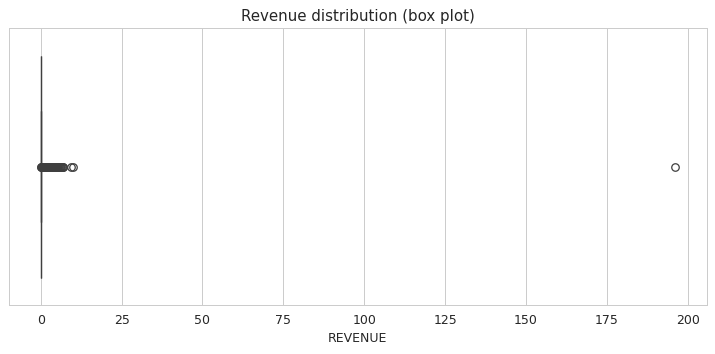

In [8]:
# Box plot of revenue to inspect the spread / outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["REVENUE"])
plt.title("Revenue distribution (box plot)")
plt.show()


It can be seen that there is a strong outlier in the data - we will find it by sorting these revenue values in descending order

In [9]:
# Sort revenue values in descending order to spot the outlier
df.sort_values("REVENUE", ascending=False).head(10)


      USER_ID VARIANT_NAME  REVENUE
8488     3342      variant   196.01
3034      630      variant    10.07
3294     1215      control     9.50
8165     4612      control     6.97
8035     2863      control     6.76
7283      191      variant     6.73
3690     2540      variant     6.23
4807     5645      variant     5.96
3198     6192      control     5.84
1839     3497      control     5.59

In [10]:
# Look at all events of user 3342 (the user with the strong outlier)
df[df["USER_ID"] == 3342]


      USER_ID VARIANT_NAME  REVENUE
8488     3342      variant   196.01

We see that there is only one outlier - in conditions of limited information, we will remove this entry and look at the distribution of data again

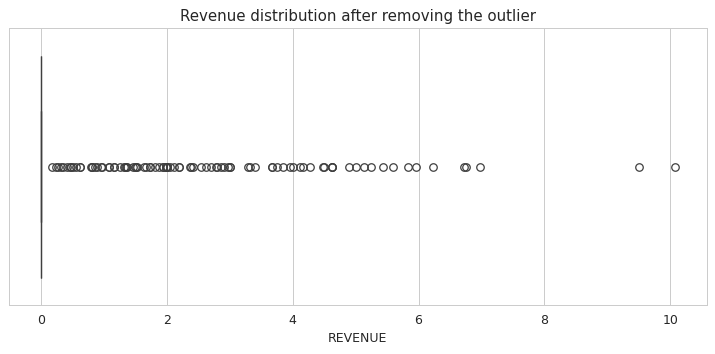

In [11]:
# Remove the single extreme outlier record and re-inspect the distribution
df = df[df["REVENUE"] < df["REVENUE"].max()].copy()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df["REVENUE"])
plt.title("Revenue distribution after removing the outlier")
plt.show()



What can you say about the users and their purchases ?

In [12]:
# Are there users with both zero-revenue and positive-revenue records?
rev_stats = df.groupby("USER_ID")["REVENUE"].agg(["min", "max"])
mixed = rev_stats[(rev_stats["min"] == 0) & (rev_stats["max"] > 0)]
print("Users with both zero and positive revenue records:", len(mixed))
mixed.head()


Users with both zero and positive revenue records: 41


         min   max
USER_ID           
219      0.0  1.82
314      0.0  1.35
864      0.0  2.19
949      0.0  2.42
1045     0.0  2.80

Can a user have records with both zero and positive revenue ?

Let's make the assumption that the records are user visits to the service, and the experimental unit is users.


In [13]:
# Aggregate to one record per user: keep the (single) group and sum revenue
df = (df.groupby("USER_ID")
        .agg(VARIANT_NAME=("VARIANT_NAME", "first"),
             REVENUE=("REVENUE", "sum"))
        .reset_index())
df.shape


(3122, 3)

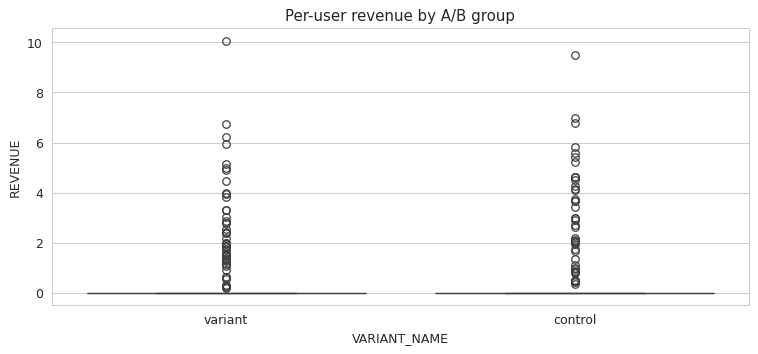

In [14]:
# Re-inspect the per-user revenue distribution by group
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x="VARIANT_NAME", y="REVENUE")
plt.title("Per-user revenue by A/B group")
plt.show()


It should be noted that during the transformation, the quantiles in the test group increased

It can be seen that in the test group, almost all quantile statistics, except for the minimum, are at a slightly lower level.

Let's look at various statistics in the context of AB test groups for all users

In [15]:
# Metrics by group for ALL users
metrics = df.groupby("VARIANT_NAME").agg(
    users=("USER_ID", "nunique"),
    total_revenue=("REVENUE", "sum"),
    mean_revenue=("REVENUE", "mean"),
    orders=("REVENUE", lambda s: (s > 0).sum()),
)

# Two additional relative metrics
metrics["avg_check_per_user"] = metrics["total_revenue"] / metrics["users"]
metrics["orders_per_user"] = metrics["orders"] / metrics["users"]

metrics


              users  total_revenue  ...  avg_check_per_user  orders_per_user
VARIANT_NAME                        ...                                     
control        1569         130.64  ...            0.083263         0.028043
variant        1553         121.72  ...            0.078377         0.030908

[2 rows x 6 columns]

What can you see in the test group about the total amount of revenue, the average check per user, and the number of orders per user slightly increased ?

Let's also see how paying users behave :

In [16]:
# Metrics by group for PAYING users only (REVENUE > 0)
paid = df[df["REVENUE"] > 0]
metrics_paid = paid.groupby("VARIANT_NAME").agg(
    users=("USER_ID", "nunique"),
    total_revenue=("REVENUE", "sum"),
    mean_revenue=("REVENUE", "mean"),
    orders=("REVENUE", lambda s: (s > 0).sum()),
)

# Two additional relative metrics
metrics_paid["avg_check_per_user"] = metrics_paid["total_revenue"] / metrics_paid["users"]
metrics_paid["orders_per_user"] = metrics_paid["orders"] / metrics_paid["users"]

metrics_paid


              users  total_revenue  ...  avg_check_per_user  orders_per_user
VARIANT_NAME                        ...                                     
control          44         130.64  ...            2.969091              1.0
variant          48         121.72  ...            2.535833              1.0

[2 rows x 6 columns]

Let's look at the distributions of all and only paying users

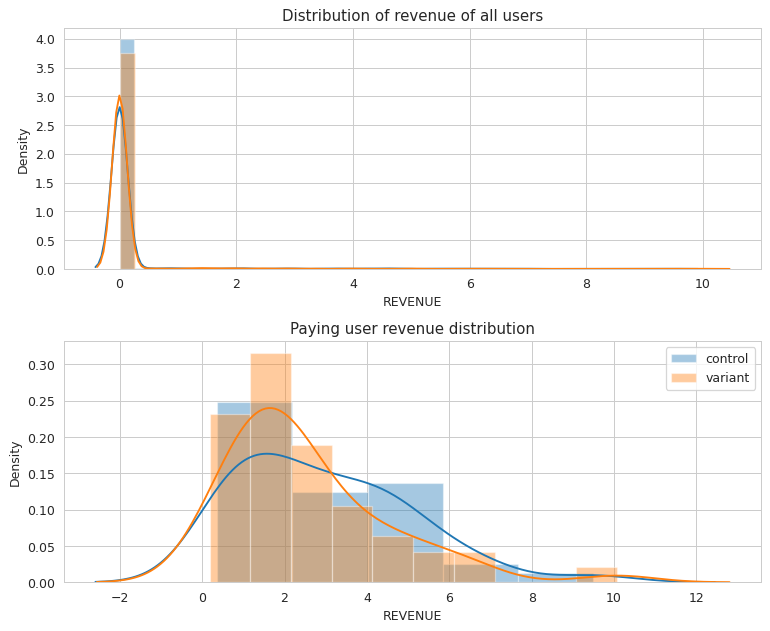

In [17]:
f, axes = plt.subplots(2, figsize=(10,8))
# build graphs of distributions of all users
sns.distplot(df.loc[df['VARIANT_NAME'] == 'control', 'REVENUE'], ax = axes[0], label='control')
sns.distplot(df.loc[df['VARIANT_NAME'] == 'variant', 'REVENUE'], ax = axes[0], label='variant')
axes[0].set_title('Distribution of revenue of all users')

# build graphs of distributions of paying users
sns.distplot(df.loc[(df['VARIANT_NAME'] == 'control') & (df['REVENUE'] > 0), 'REVENUE'], ax = axes[1], label='control' )
sns.distplot(df.loc[(df['VARIANT_NAME'] == 'variant') & (df['REVENUE'] > 0), 'REVENUE'], ax = axes[1], label='variant' )
axes[1].set_title('Paying user revenue distribution')
plt.legend()
plt.subplots_adjust(hspace = 0.3)

### Statistical Analysis <a name="Statistical"/>

#### Checking if the distribution is normal

Based on their previous graph, we see that the data is not normally distributed.

In [18]:
# Shapiro-Wilk test for normality on each group's revenue
for g in df["VARIANT_NAME"].unique():
    sample = df.loc[df["VARIANT_NAME"] == g, "REVENUE"]
    # Shapiro is limited to 5000 samples; subsample if needed
    s = sample.sample(min(5000, len(sample)), random_state=0)
    stat, p = shapiro(s)
    print(f"{g}: W={stat:.4f}, p-value={p:.3e} -> "
          f"{'reject' if p < 0.05 else 'fail to reject'} normality")


variant: W=0.1262, p-value=1.719e-64 -> reject normality
control: W=0.1233, p-value=8.947e-65 -> reject normality


Is the null hypothesis about the normal distribution of the data rejected ?

#### Mann-Whitney test

Let's check the value of the statistics of the Mann-Whitney test. Some sources have a limitation of applicability in case of duplicate data. There are a lot of repetitions in our sample, and especially a lot of zero values, so in this case we need to be careful about this criterion.

In [19]:
(df['REVENUE'] == 0).value_counts()

REVENUE
True     3030
False      92
Name: count, dtype: int64

In [20]:
# Mann-Whitney U test on ALL users
control_rev = df.loc[df["VARIANT_NAME"] == "control", "REVENUE"]
variant_rev = df.loc[df["VARIANT_NAME"] == "variant", "REVENUE"]
stat, p = mannwhitneyu(control_rev, variant_rev, alternative="two-sided")
print(f"All users  -> U={stat:.1f}, p-value={p:.4f} -> "
      f"{'significant' if p < 0.05 else 'not significant'}")


All users  -> U=1214976.0, p-value=0.6496 -> not significant


In [21]:
# Mann-Whitney U test on PAYING users only
control_paid_rev = df.loc[(df["VARIANT_NAME"] == "control") & (df["REVENUE"] > 0), "REVENUE"]
variant_paid_rev = df.loc[(df["VARIANT_NAME"] == "variant") & (df["REVENUE"] > 0), "REVENUE"]
stat, p = mannwhitneyu(control_paid_rev, variant_paid_rev, alternative="two-sided")
print(f"Paying users -> U={stat:.1f}, p-value={p:.4f} -> "
      f"{'significant' if p < 0.05 else 'not significant'}")


Paying users -> U=1193.5, p-value=0.2842 -> not significant


#### Bootstrap

In order to get more complete information about the differences between the average values of the ab test groups, we will use bootstap.

Let's create a function to get back samples and get a confidence interval, and then look at the sample statistics

In [22]:
def get_bootstrap_samples(data, n_samples=1000):
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples

def stat_intervals(stat, alpha=0.05):
    boundaries = np.percentile(stat, [100 * alpha / 2., 100 * (1 - alpha / 2.)])
    return boundaries

In [23]:
# Bootstrap samples for ALL users
np.random.seed(0)
control = get_bootstrap_samples(
    df.loc[df["VARIANT_NAME"] == "control", "REVENUE"].values, 1000)
variant = get_bootstrap_samples(
    df.loc[df["VARIANT_NAME"] == "variant", "REVENUE"].values, 1000)
control.shape, variant.shape


((1000, 1569), (1000, 1553))

In [24]:
# Bootstrap samples for PAYING users only
np.random.seed(0)
control_paid = get_bootstrap_samples(
    df.loc[(df["VARIANT_NAME"] == "control") & (df["REVENUE"] > 0), "REVENUE"].values, 1000)
variant_paid = get_bootstrap_samples(
    df.loc[(df["VARIANT_NAME"] == "variant") & (df["REVENUE"] > 0), "REVENUE"].values, 1000)
control_paid.shape, variant_paid.shape


((1000, 44), (1000, 48))

Let's look at the distribution of means in the ab test groups

Text(0.5, 1.0, 'Sample mean distribution for all users')

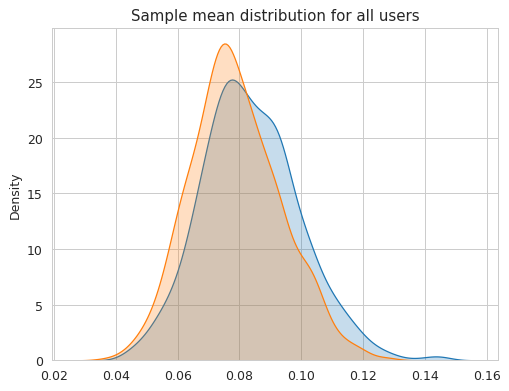

In [25]:
f, ax = plt.subplots()
# plt.figure(figsize=(20,5))
sns.kdeplot(np.mean(control, axis=1), shade=True, label='control')
sns.kdeplot(np.mean(variant, axis=1), shade=True, label='variant')
plt.title('Sample mean distribution for all users')

Text(0.5, 1.0, 'Sample mean distribution for paying users')

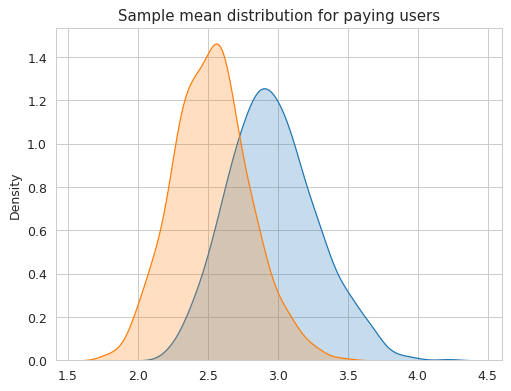

In [26]:
f, ax = plt.subplots()
# plt.figure(figsize=(20,5))
sns.kdeplot(np.mean(control_paid, axis=1), shade=True, label='control')
sns.kdeplot(np.mean(variant_paid, axis=1), shade=True, label='variant')
plt.title('Sample mean distribution for paying users')

Do you see any difference ? What about the confidence intervals ? Conclude.

Let's evaluate the difference between the groups: look at the distribution of the mean difference and build confidence intervals for it. To do this, we will create a function for visualization

In [27]:
def plot_distribution_and_stat_intervals(variant, control, title, alpha=0.05):
    """ Plot the distribution of the mean difference and return the confidence intervals """
    f, ax = plt.subplots()
    # get data for coloring confidence intervals
    _kax = sns.kdeplot(variant - control, shade=True)
    _lines = _kax.get_lines()
    if _lines:
        points = _lines[0].get_data()
    else:
        # newer seaborn: filled kde exposes no Line2D; recompute the curve
        from scipy.stats import gaussian_kde
        _d = np.asarray(variant - control)
        _g = gaussian_kde(_d)
        _xs = np.linspace(_d.min(), _d.max(), 200)
        points = (_xs, _g(_xs))
    x = points[0]
    y = points[1]
    ymin, ymax = plt.ylim()
    # highlight the zero value and the bounds of the confidence interval
    plt.vlines(0, 0, ymax, label='0', color='gray')
    plt.vlines(stat_intervals(variant - control, alpha)[0], 0, ymax, linestyles="dashed")
    plt.vlines(stat_intervals(variant - control, alpha)[1], 0, ymax, linestyles="dashed")
    # color the confidence interval and zones outside it
    plt.fill_between(x,y,
                     where = (x >= stat_intervals(variant - control, alpha)[1]),
                     color='gainsboro')
    plt.fill_between(x,y,
                     where = (x <= stat_intervals(variant - control, alpha)[0]),
                     color='gainsboro')
    plt.fill_between(x,y,
                     where = ((x >= stat_intervals(variant - control, alpha)[0])
                              & (x <= stat_intervals(variant - control, alpha)[1])),
                     color='red',
                     label = '95% confidence interval')
    plt.title(f'Distribution of difference between means (variant - control) {title}; {100*(1-alpha)}% Confidence interval for difference of means: {stat_intervals(variant - control, alpha)}')
    plt.legend(prop={'size':13})
    # return confidence interval data
    return stat_intervals(variant - control)

Let's build a graph of the distribution of the difference in the means and get a confidence interval

For all users

array([-0.0484158 ,  0.03790517])

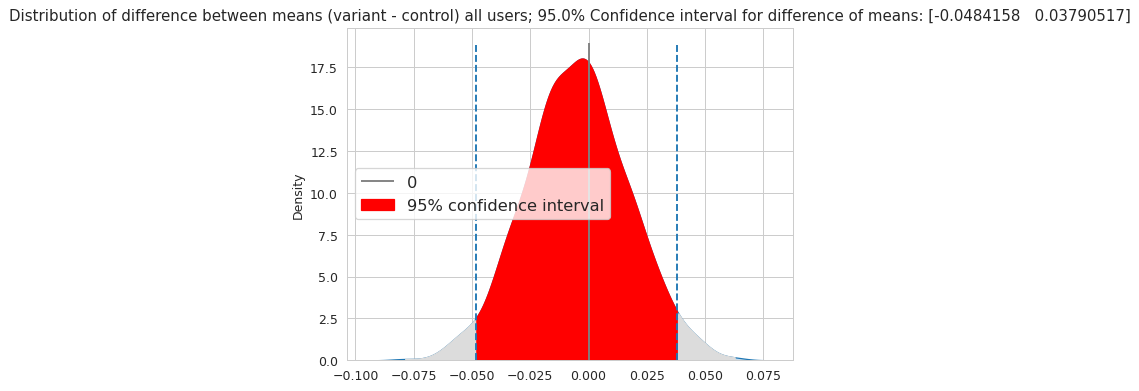

In [28]:
plot_distribution_and_stat_intervals(np.mean(variant, axis=1),
                                     np.mean(control, axis=1),
                                     title='all users')

array([-1.30384328,  0.36274669])

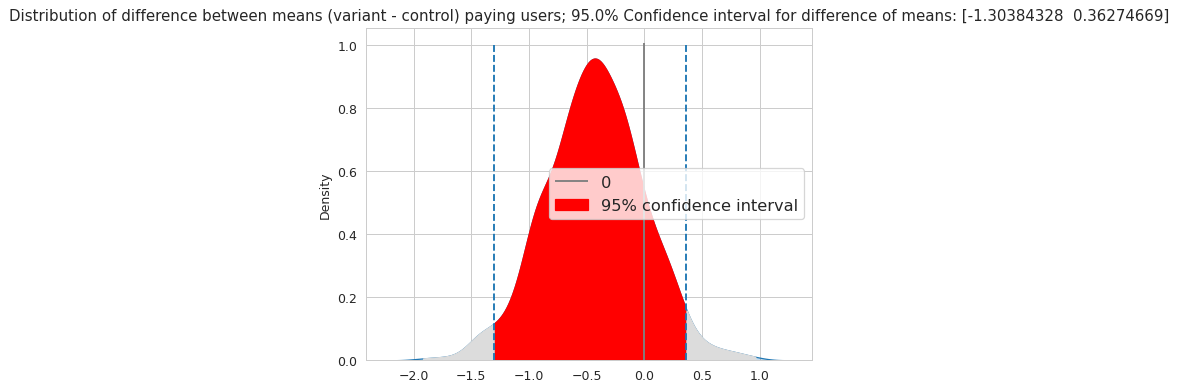

In [29]:
plot_distribution_and_stat_intervals(np.mean(variant_paid, axis=1),
                                     np.mean(control_paid, axis=1),
                                     title='paying users')

What can you observe ? Conclude about the statistical change in average revenue between A/B test groups.


### Conclusions <a name="Conclusions"/>

**Data quality / preparation**
- ~38% of users appeared in **both** A/B groups. These were excluded because a user exposed to both control and variant cannot be cleanly attributed to one treatment (contamination of the experiment).
- A single extreme **outlier** (user 3342, revenue ≈ 196) dwarfed all other purchases (next highest ≈ 10) and was removed under limited information.
- Records were aggregated to **one row per user** (sum of revenue), since the experimental unit is the user.

**Statistical analysis**
- **Normality:** the Shapiro-Wilk test strongly **rejects** normality (p ≈ 0) for both groups — revenue is heavily zero-inflated and right-skewed, so a t-test on raw revenue is inappropriate.
- **Mann-Whitney U:** no significant difference for all users (p ≈ 0.65) nor for paying users only (p ≈ 0.28).
- **Bootstrap:** the confidence interval for the difference of means (variant − control) **contains 0** for both all users and paying users.

**Overall:** there is **no statistically significant difference** in average revenue between the control and variant groups. The variant shows a marginally higher orders-per-user rate but a marginally lower average check, and neither effect is significant. With the current data we cannot conclude that the new functionality changed revenue.